In [1]:
import numpy as np
import matplotlib.pyplot as plt

Et signal af formen

$$
y(x) = 11 \cdot \sin(x) − 3 \cdot cos(7x), \; \; 0 \leq x \leq 12,
$$

sendes igennem et kabel og forstyrres dermed af støj. Vi ønsker at modificere
signalet, som er modtaget, så at støjeffekten mindskes.

$\pagebreak$

## (a) {-}

Lav en python plot af funktionen $y(x)$ via f.eks. $n = 200$ $x$-værdier jævnt
fordelt over intervallet $[0,12]$.

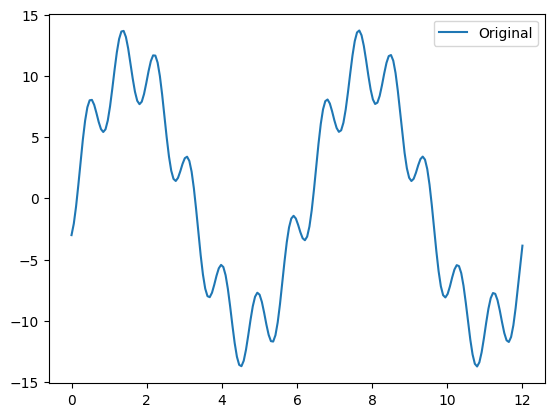

In [2]:
n = 200
x = np.linspace(0, 12, n)[:, np.newaxis]    # x-værdier som en søjlevektor
y = 11 * np.sin(x) - 3 * np.cos(7 * x)      # beregner y-værdier ud fra x

fig, ax = plt.subplots()
ax.plot(x, y, label = "Original")
plt.legend()

$\pagebreak$

## (b) {-}

Brug

```py
rng = np.random.default_rng()
støj = rng.standard_normal(n)
```

til at tilføje $y$ i formen: $y_{\text{støj}} = y + \text{rng.standard\_normal(n)}$, og plot resultatet.

In [3]:
# Definerer y med støj
rng = np.random.default_rng()
y_noise = (y[:,0] + rng.standard_normal(n))[:, np.newaxis]

# Beregner fejl fra støj som differens til original y værdier
noise_fejl = y_noise - y
print("Fejl fra støj:", np.linalg.norm(noise_fejl))   # Størrelse af fejl

Fejl fra støj: 13.968601913880356


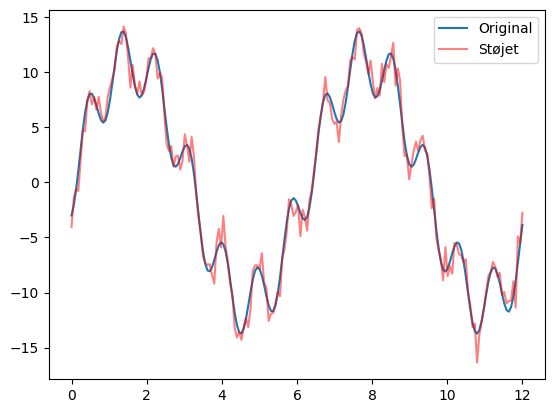

In [4]:
fig, ax = plt.subplots()
ax.plot(x, y, label = "Original")
ax.plot(x, y_noise, color='red', alpha=0.5, label = "Støjet")
plt.legend()

## (c) {-}

Givet en vektor v og et heltal offset vil funktionen np.diag(v, offset)
danne en matrix med v langs en skrå linje hvor startpunktet er forskudt fra det
øverste venstre hjørne med offset.

Brug

```python
np.diag()
```

eventuelt kombineret med

```python
np.ones
```

tre gange til at konstruere matricen $A \in \mathbb{R}^{n \times n}$, der har formen

![matrix](C:/Users/henri/OneDrive%20-%20Aarhus%20universitet/2.%20Semester/Numerisk%20Lineær%20Algebra/TØ/Opgavesæt%203/Billeder/Matrix.png)

In [12]:
# Diagonalerne er opdelt for nemmere overblik
A = np.diag(np.ones(n) * 1/3, 0)
A += np.diag(np.ones(n-1) * 1/3, -1) 
A += np.diag(np.ones(n-1) * 1/3, 1)
print(A)

[[0.33333333 0.33333333 0.         ... 0.         0.         0.        ]
 [0.33333333 0.33333333 0.33333333 ... 0.         0.         0.        ]
 [0.         0.33333333 0.33333333 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.33333333 0.33333333 0.        ]
 [0.         0.         0.         ... 0.33333333 0.33333333 0.33333333]
 [0.         0.         0.         ... 0.         0.33333333 0.33333333]]


$\pagebreak$

## (d) {-}

Plot $A y_{støj}$. Det burde ses at den har en form, som er tættere på $y$ end på
$y_{støj}$. Giv en kort forklaring på hvorfor dette sker.

In [105]:
# Beregner fejl efter påførelse af A på samme måde
y_A = A @ y_noise
A_fejl = y_A - y
print("Fejl med A:", np.linalg.norm(A_fejl))

Fejl med A: 7.237379618770103


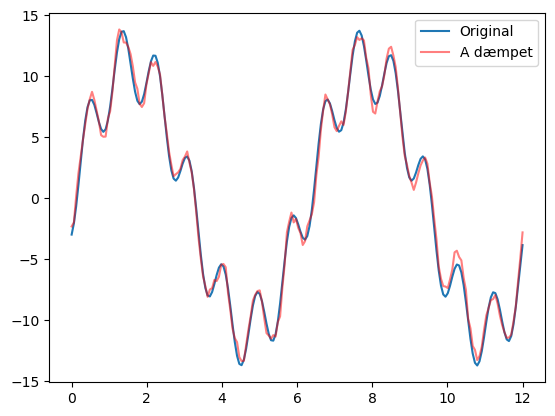

In [106]:
fig, ax = plt.subplots()
ax.plot(x, y, label = "Original")
ax.plot(x, y_A, color='red', alpha=0.5, label = "A dæmpet")
plt.legend()

$\pagebreak$

Når produktet af den støjfyldte data og matricen $A$ tages vil det have følgende form:

$$
A y_{støj} =
\begin{bmatrix}
\frac{1}{3} y_{0} + \frac{1}{3} y_{1} \\
\frac{1}{3} y_{0} + \frac{1}{3} y_{1} + \frac{1}{3} y_{2} \\
\frac{1}{3} y_{1} + \frac{1}{3} y_{2} + \frac{1}{3} y_{3} \\
\vdots \\
\frac{1}{3} y_{n-3} + \frac{1}{3} y_{n-2} + \frac{1}{3} y_{n-1} \\
\frac{1}{3} y_{n-2} + \frac{1}{3} y_{n-1} \\
\frac{1}{3} y_{n-1}
\end{bmatrix}
$$

Dette kan ses som en form for løbende gennemsnit i det, at den tager en y-værdi og dens ene eller to omkringliggende punkt(er), summerer dem og deler dem med 3. Beregningen passer nærmest perfekt med en middelværdi. Når middelværdien tages svarer det til at "bløde" forskellen mellem y-værdierne ud, hvilket gør at støjen ikke har lige så stor effekt på den enkelte y-værdi. Det kan også ses i fejlen, da den går fra 13.6 til kun 7.2. Udblødningne af værdierne resulterer også i en tilsvarende udblødning i kurven, som får den til at ligne den originale kurve mere.

## (e) {-}

Ved at ændre den relative vægtning af diagonalen i $A$ i forhold til de andre
indgange, og / eller ved at bruge nogle få ekstra diagonaler som er ikke
nul, giv et eksempel på en matrix $B$ hvor $B y_{støj}$ er har bedre støjreduktion
end $A y_{støj}$. Bekræft at det samme $B$ kan bruges når der startes med en ny
tilfældig $y_{støj}$.

In [107]:
B = np.diag(np.ones(n) * 6/20) 
B += np.diag(np.ones(n-1) * 5/20, -1) + np.diag(np.ones(n-1) * 5/20, 1)
B += np.diag(np.ones(n-2) * 2/20, -2) + np.diag(np.ones(n-2) * 2/20, 2)

print(B)

[[0.3  0.25 0.1  ... 0.   0.   0.  ]
 [0.25 0.3  0.25 ... 0.   0.   0.  ]
 [0.1  0.25 0.3  ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.3  0.25 0.1 ]
 [0.   0.   0.   ... 0.25 0.3  0.25]
 [0.   0.   0.   ... 0.1  0.25 0.3 ]]


In [108]:
# Beregner fejl med B istedet for A
y_B = B @ y_noise
B_fejl = y_B - y
print("Fejl med B:", np.linalg.norm(B_fejl))

Fejl med B: 6.448651907254257


$\pagebreak$

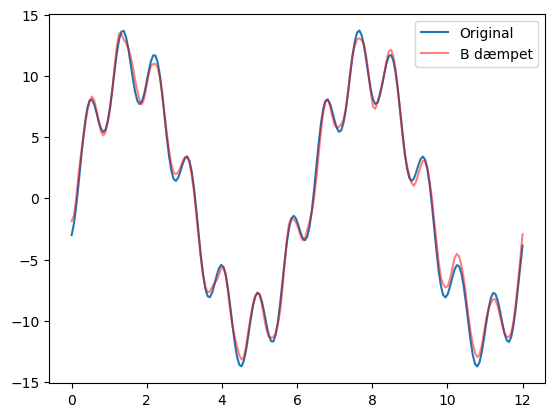

In [109]:
fig, ax = plt.subplots()
ax.plot(x, y, label = "Original")
ax.plot(x, y_B, color='red', alpha=0.5, label = "B dæmpet")
plt.legend()

Ideen bag den nye matrix er, at hver værdi i y-aksen bliver "prioriteret" på et tidspunkt med en højere vægt end det som er påført de omkringliggende matricer. Dette gør at der stadig bliver blødet ud som før, men at værdierne beholder noget tættere på deres originalv værdi, i tilfældet af støjen ikke fik værdien alt for langt fra det rigtige. Derudover er der tilføjet to yderligere diagonaler, hvilket blot bløder kurven ud yderligere, hvilket også kan ses relativt til $A y_{støj}$. Det kan også ses mere objektivt, at B får støjen udlignet mere gennem fejlen, da den går fra 7.2 med A til 6.4 med B.

$\pagebreak$

For neden er der lavet en ny tilfældig støj med tilsvarende grafer og fejl med A og B, hvor det kan ses at lignende resultater kan genskabes.

In [110]:
# Ny støj defineres
rng_ny = np.random.default_rng()
y_noise_ny = (y[:,0] + rng.standard_normal(n))[:, np.newaxis]

print("Fejl fra støj", np.linalg.norm(y_noise_ny - y))

# Fejl i med begge matricer findes:
y_A_ny = A @ y_noise_ny
A_fejl_ny = y_A_ny - y
print("Fejl med A-matrix", np.linalg.norm(A_fejl_ny))

y_B_ny = B @ y_noise_ny
B_fejl_ny = y_B_ny - y
print("Fejl med B-matrix", np.linalg.norm(B_fejl_ny))

Fejl fra støj 13.056543671170726
Fejl med A-matrix 8.048486633989356
Fejl med B-matrix 7.44083145032017


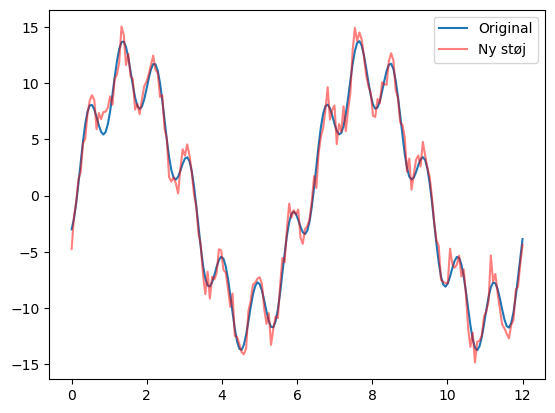

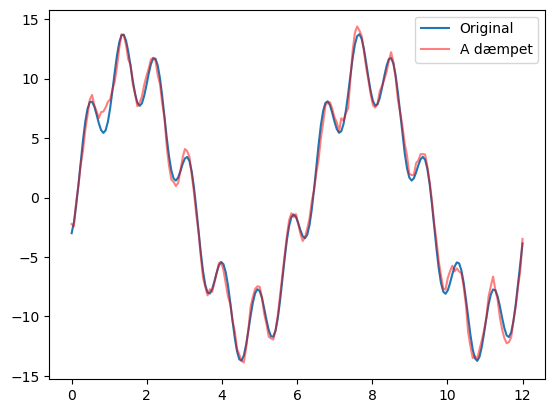

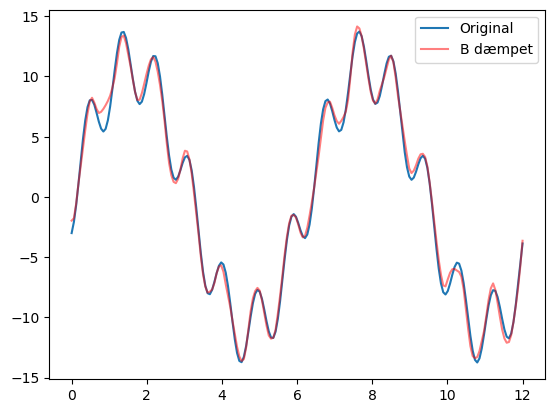

In [111]:
fig, ax = plt.subplots()
ax.plot(x, y, label = "Original")
ax.plot(x, y_noise_ny, color='red', alpha=0.5, label = "Ny støj")
plt.legend()

fig, ax = plt.subplots()
ax.plot(x, y, label = "Original")
ax.plot(x, y_A_ny, color='red', alpha=0.5, label = "A dæmpet")
plt.legend()

fig, ax = plt.subplots()
ax.plot(x, y, label = "Original")
ax.plot(x, y_B_ny, color='red', alpha=0.5, label = "B dæmpet")
plt.legend()